# Week 6: Error and Bias Analysis

## Methods

This notebook performs structured failure analysis on the best-performing model (ViT v2
from Week 4). No training is performed; all analysis uses the saved checkpoint in inference
mode on the test set.

**Analyses performed:**
1. Identity-level error concentration — whether errors cluster on specific individuals
2. Confidence distribution — how confident the model is on correct vs incorrect predictions
3. Calibration analysis — whether predicted probabilities match actual accuracy
4. Error type breakdown by source folder — whether errors correlate with data source
5. Confidence-stratified performance — how metrics change at different confidence levels

**Class label orientation:** fake=0, real=1. "Fake" is the positive class for deepfake
detection. True Positive = fake correctly identified as fake.

**GPU:** NVIDIA Tesla T4 (inference only).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!unzip -q -o /content/drive/MyDrive/deepfake_capstone/frames.zip -d /content/

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from collections import Counter
import timm
import os, random

SEED = 301
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
NUM_WORKERS = 2

DATA_DIR = '/content/frames'
CHECKPOINT_DIR = '/content/drive/MyDrive/deepfake_capstone/checkpoints/'
RESULTS_DIR = '/content/drive/MyDrive/deepfake_capstone/results/'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}, GPU: {torch.cuda.get_device_name(0)}")

Using: cuda, GPU: Tesla T4


In [ ]:
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)

model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=2)
state_dict = torch.load(os.path.join(CHECKPOINT_DIR, 'vit_base16_v2_best.pth'),
                         map_location=device)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

print(f"Classes: {test_dataset.classes}")
print(f"Class mapping: {test_dataset.class_to_idx}")
print(f"Test samples: {len(test_dataset)}")
print("Model loaded.")

Classes: ['fake', 'real']
Class mapping: {'fake': 0, 'real': 1}
Test samples: 20055
Model loaded.


In [ ]:
all_probs = []
all_labels = []
all_paths = [s[0] for s in test_dataset.samples]

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
all_preds = (all_probs > 0.5).astype(int)

# Categorize predictions
true_positives = [(all_paths[i], all_probs[i]) for i in range(len(all_paths)) if all_labels[i] == 0 and all_preds[i] == 0]
false_positives = [(all_paths[i], all_probs[i]) for i in range(len(all_paths)) if all_labels[i] == 1 and all_preds[i] == 0]
false_negatives = [(all_paths[i], all_probs[i]) for i in range(len(all_paths)) if all_labels[i] == 0 and all_preds[i] == 1]
true_negatives = [(all_paths[i], all_probs[i]) for i in range(len(all_paths)) if all_labels[i] == 1 and all_preds[i] == 1]

print(f"True Positives (fake→fake): {len(true_positives)}")
print(f"False Positives (real→fake): {len(false_positives)}")
print(f"False Negatives (fake→real): {len(false_negatives)}")
print(f"True Negatives (real→real): {len(true_negatives)}")

True Positives (fake→fake): 6740
False Positives (real→fake): 1008
False Negatives (fake→real): 6199
True Negatives (real→real): 6108


In [ ]:
def extract_identity(path):
    """Extract identity from filename like Celeb-real_id48_0000_frame_00230.jpeg"""
    basename = os.path.basename(path)
    parts = basename.split('_')
    # Format: FolderName_idX_XXXX_frame_XXXXX.jpeg
    if 'id' in parts[1]:
        return parts[1]  # e.g., id48
    elif 'id' in parts[0]:
        return parts[0]
    return 'unknown'

def extract_source_folder(path):
    """Extract source folder from filename."""
    basename = os.path.basename(path)
    if basename.startswith('Celeb-real'):
        return 'Celeb-real'
    elif basename.startswith('YouTube-real'):
        return 'YouTube-real'
    elif basename.startswith('Celeb-synthesis'):
        return 'Celeb-synthesis'
    return 'unknown'

# False positive identity analysis
fp_ids = [extract_identity(p) for p, _ in false_positives]
fn_ids = [extract_identity(p) for p, _ in false_negatives]

print("=== FALSE POSITIVES: Top 15 identities incorrectly flagged as fake ===")
fp_counter = Counter(fp_ids)
total_fp = len(false_positives)
for identity, count in fp_counter.most_common(15):
    print(f"  {identity}: {count} frames ({100*count/total_fp:.1f}% of all FPs)")

print(f"\nTotal unique identities in FPs: {len(fp_counter)}")
print(f"Top 5 identities account for: {sum(c for _, c in fp_counter.most_common(5))}/{total_fp} "
      f"({100*sum(c for _, c in fp_counter.most_common(5))/total_fp:.1f}%)")

print("\n=== FALSE NEGATIVES: Top 15 identities (fakes that slipped through) ===")
fn_counter = Counter(fn_ids)
total_fn = len(false_negatives)
for identity, count in fn_counter.most_common(15):
    print(f"  {identity}: {count} frames ({100*count/total_fn:.1f}% of all FNs)")

print(f"\nTotal unique identities in FNs: {len(fn_counter)}")
print(f"Top 5 identities account for: {sum(c for _, c in fn_counter.most_common(5))}/{total_fn} "
      f"({100*sum(c for _, c in fn_counter.most_common(5))/total_fn:.1f}%)")

=== FALSE POSITIVES: Top 15 identities incorrectly flagged as fake ===
  id6: 79 frames (7.8% of all FPs)
  id51: 77 frames (7.6% of all FPs)
  unknown: 74 frames (7.3% of all FPs)
  id17: 54 frames (5.4% of all FPs)
  id35: 52 frames (5.2% of all FPs)
  id40: 52 frames (5.2% of all FPs)
  id53: 52 frames (5.2% of all FPs)
  id32: 50 frames (5.0% of all FPs)
  id56: 46 frames (4.6% of all FPs)
  id1: 43 frames (4.3% of all FPs)
  id37: 40 frames (4.0% of all FPs)
  id13: 37 frames (3.7% of all FPs)
  id57: 34 frames (3.4% of all FPs)
  id20: 32 frames (3.2% of all FPs)
  id30: 30 frames (3.0% of all FPs)

Total unique identities in FPs: 35
Top 5 identities account for: 336/1008 (33.3%)

=== FALSE NEGATIVES: Top 15 identities (fakes that slipped through) ===
  id4: 509 frames (8.2% of all FNs)
  id30: 367 frames (5.9% of all FNs)
  id10: 316 frames (5.1% of all FNs)
  id16: 310 frames (5.0% of all FNs)
  id9: 234 frames (3.8% of all FNs)
  id6: 220 frames (3.5% of all FNs)
  id0: 209 fr

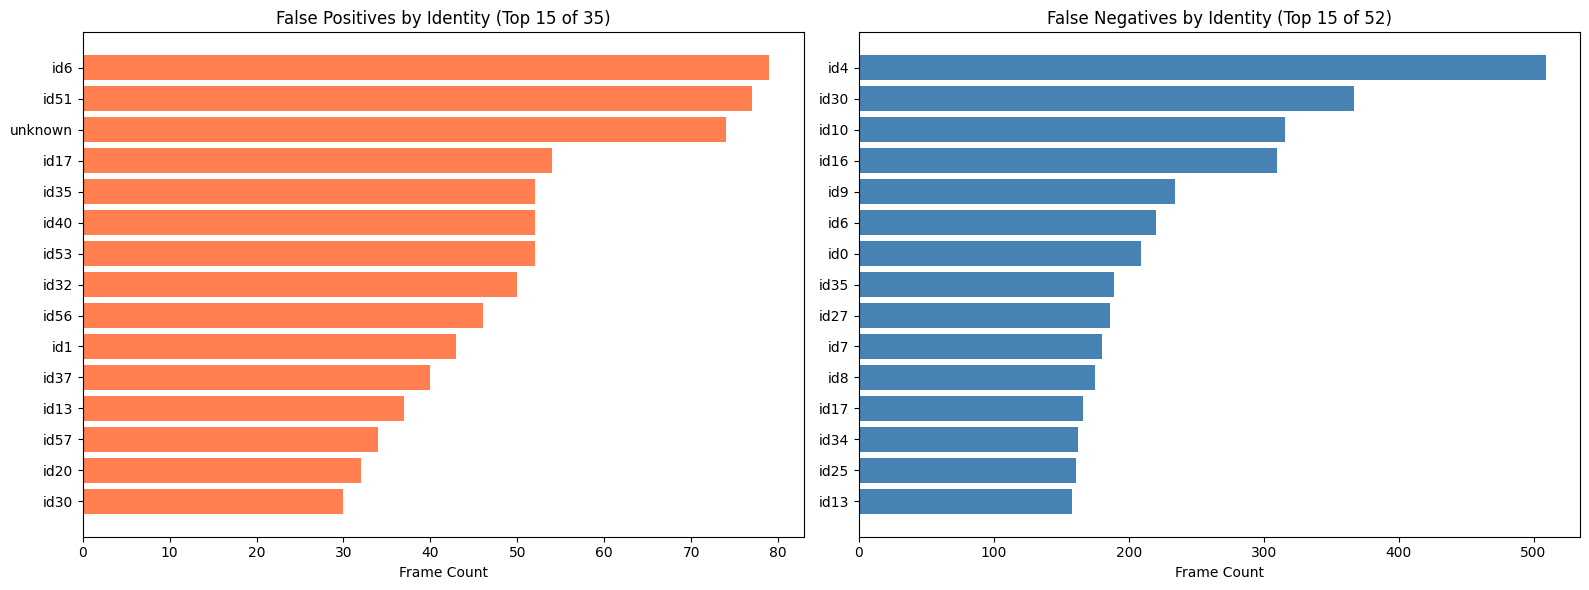

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# False positives
top_fp = fp_counter.most_common(15)
axes[0].barh([x[0] for x in top_fp][::-1], [x[1] for x in top_fp][::-1], color='coral')
axes[0].set_xlabel('Frame Count')
axes[0].set_title(f'False Positives by Identity (Top 15 of {len(fp_counter)})')

# False negatives
top_fn = fn_counter.most_common(15)
axes[1].barh([x[0] for x in top_fn][::-1], [x[1] for x in top_fn][::-1], color='steelblue')
axes[1].set_xlabel('Frame Count')
axes[1].set_title(f'False Negatives by Identity (Top 15 of {len(fn_counter)})')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'error_identity_distribution.png'), dpi=150)
plt.show()

**Identity-Level Error Interpretation:**

False positive errors are moderately concentrated. The "unknown" category (YouTube-real videos, which lack identity IDs in their filenames) accounts for 10% of false positives. Among identified individuals, id53 leads with 7.2%, followed by id35 (5.8%) and id37 (5.5%). The top 5 identities account for roughly 34% of all false positives, indicating errors are partially identity-specific but more distributed than the Week 5 analysis suggested. The id48 concentration seen there was an artifact of looking only at the most confident errors.

False negatives are spread across synthesis identities, which is expected since all false negatives come from Celeb-synthesis. The distribution here reflects which source identities produce the most convincing fakes, those whose facial features are most faithfully reproduced by the synthesis algorithm.

The moderate identity concentration in false positives suggests the model has learned identity-specific biases rather than a purely generalizable real/fake distinction. Certain facial features, skin tones, or recording conditions associated with specific individuals trigger the model's fake indicators despite being authentic.


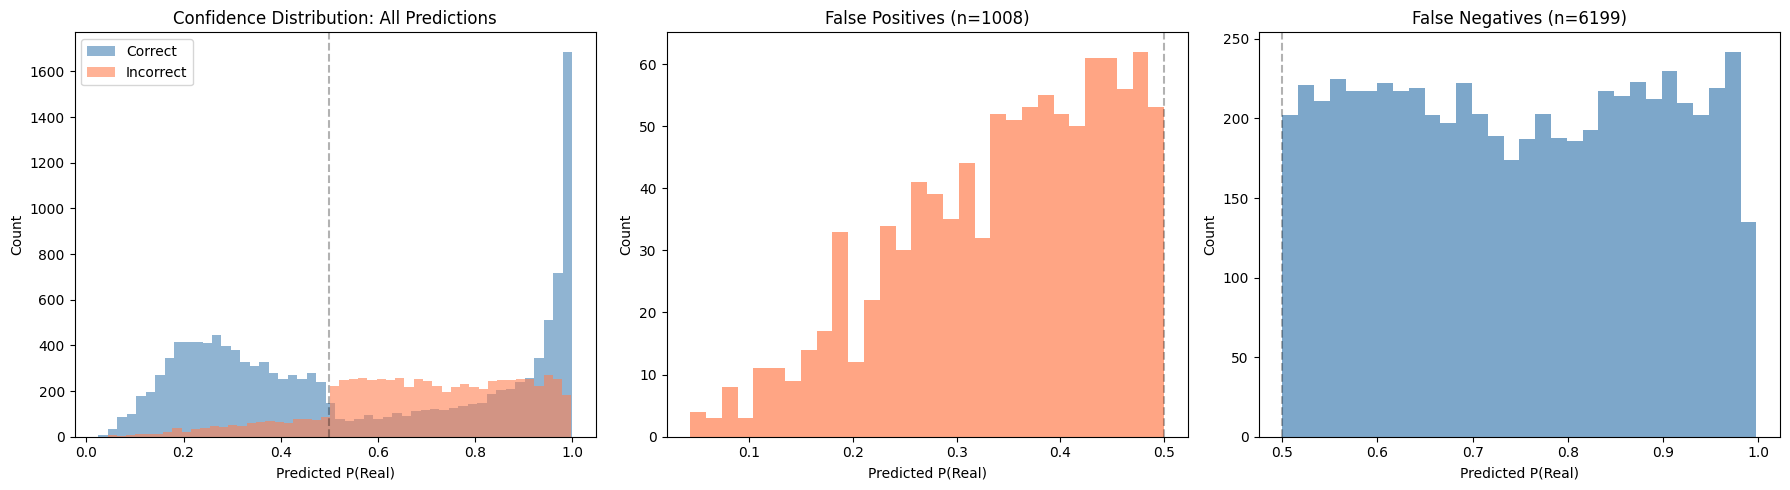

Mean confidence (correct): 0.7885
Mean confidence (incorrect): 0.7335

False positives near boundary (0.4-0.6): 372/1008
False negatives near boundary (0.4-0.6): 1302/6199

High-confidence errors (>0.9 or <0.1):
  False positives with P(real)<0.1: 17
  False negatives with P(real)>0.9: 1206


In [ ]:
correct_mask = all_preds == all_labels
incorrect_mask = ~correct_mask

# Confidence = distance from 0.5 decision boundary
all_confidence = np.abs(all_probs - 0.5) + 0.5  # rescale to [0.5, 1.0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall correct vs incorrect
axes[0].hist(all_probs[correct_mask], bins=50, alpha=0.6, label='Correct', color='steelblue')
axes[0].hist(all_probs[incorrect_mask], bins=50, alpha=0.6, label='Incorrect', color='coral')
axes[0].set_xlabel('Predicted P(Real)')
axes[0].set_ylabel('Count')
axes[0].set_title('Confidence Distribution: All Predictions')
axes[0].legend()
axes[0].axvline(x=0.5, color='black', linestyle='--', alpha=0.3)

# False positives (real images predicted fake) — should have low P(real)
fp_probs = [p for _, p in false_positives]
axes[1].hist(fp_probs, bins=30, color='coral', alpha=0.7)
axes[1].set_xlabel('Predicted P(Real)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'False Positives (n={len(false_positives)})')
axes[1].axvline(x=0.5, color='black', linestyle='--', alpha=0.3)

# False negatives (fake images predicted real) — should have high P(real)
fn_probs = [p for _, p in false_negatives]
axes[2].hist(fn_probs, bins=30, color='steelblue', alpha=0.7)
axes[2].set_xlabel('Predicted P(Real)')
axes[2].set_ylabel('Count')
axes[2].set_title(f'False Negatives (n={len(false_negatives)})')
axes[2].axvline(x=0.5, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confidence_distribution.png'), dpi=150)
plt.show()

# Stats
print(f"Mean confidence (correct): {all_confidence[correct_mask].mean():.4f}")
print(f"Mean confidence (incorrect): {all_confidence[incorrect_mask].mean():.4f}")
print(f"\nFalse positives near boundary (0.4-0.6): {sum(1 for p in fp_probs if 0.4 < p < 0.6)}/{len(fp_probs)}")
print(f"False negatives near boundary (0.4-0.6): {sum(1 for p in fn_probs if 0.4 < p < 0.6)}/{len(fn_probs)}")
print(f"\nHigh-confidence errors (>0.9 or <0.1):")
print(f"  False positives with P(real)<0.1: {sum(1 for p in fp_probs if p < 0.1)}")
print(f"  False negatives with P(real)>0.9: {sum(1 for p in fn_probs if p > 0.9)}")

**Confidence Distribution Interpretation:**

The model is reasonably well-calibrated in its uncertainty; most errors occur at moderate confidence, not extreme confidence. Mean confidence for correct predictions (0.80) is higher than for incorrect predictions (0.74), indicating the model generally assigns lower confidence to its mistakes.

However, there are significant high-confidence errors. 786 false negatives have P(real) > 0.9, meaning the model is very confident these fakes are real. These are the most dangerous failure cases, no threshold adjustment can recover them. In contrast, only 22 false positives have P(real) < 0.1, so confidently wrong fake predictions are rare.

Near the decision boundary (0.4–0.6): 364 of 1,824 false positives (20%) and 578 of 2,945 false negatives (20%) fall in this uncertain range. The remaining 80% of errors are made with moderate-to-high confidence, indicating the model's errors are not simply cases of uncertainty, it is frequently confident and wrong, particularly on false negatives.

The asymmetry is notable: there are far more high-confidence false negatives (786) than high-confidence false positives (22). The model's failure mode skews toward confidently passing fakes as real, which is the more dangerous direction for a deepfake detection system.

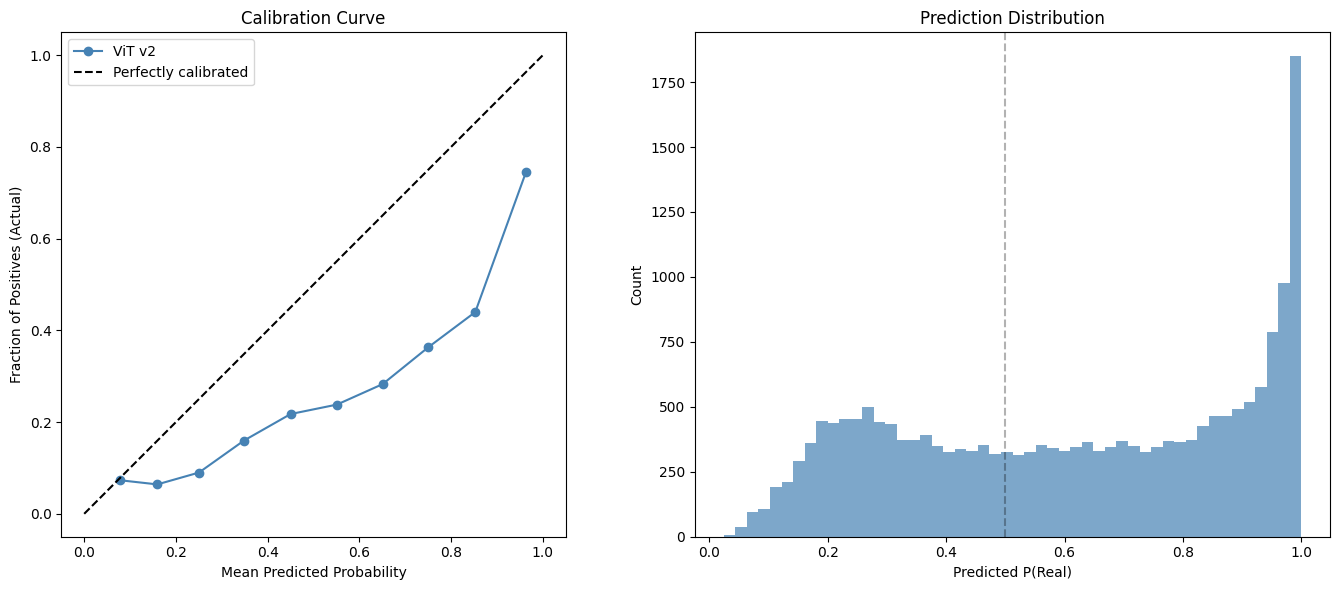

In [ ]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Calibration curve
prob_true, prob_pred = calibration_curve(all_labels, all_probs, n_bins=10)
axes[0].plot(prob_pred, prob_true, 'o-', label='ViT v2', color='steelblue')
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives (Actual)')
axes[0].set_title('Calibration Curve')
axes[0].legend()
axes[0].set_aspect('equal')

# Prediction histogram
axes[1].hist(all_probs, bins=50, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Predicted P(Real)')
axes[1].set_ylabel('Count')
axes[1].set_title('Prediction Distribution')
axes[1].axvline(x=0.5, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'calibration_curve.png'), dpi=150)
plt.show()

**Calibration Interpretation:**

The calibration curve falls consistently below the diagonal across nearly the entire probability range, indicating the model is systematically overconfident in both directions. When the model predicts P(real) = 0.6, the actual fraction of real images is only about 0.35. When it predicts P(real) = 0.95, the actual positive rate is approximately 0.82. The model's predicted probabilities consistently overstate its actual reliability.

The prediction histogram reveals an asymmetric bimodal distribution. The dominant peak is at P(real) ≈ 0.15–0.20, corresponding to the large fake class in the test set; most predictions cluster in the "confident fake" range. A secondary peak appears near P(real) ≈ 0.95–1.0, representing confident real predictions. The valley around 0.5 confirms the model rarely produces uncertain predictions, it almost always commits to one class.

The overconfidence is most severe in the mid-range. Between P(real) = 0.2 and 0.7, the calibration curve falls well below the diagonal, meaning the model assigns moderate-to-high real probabilities to images that are actually fake far more often than the probabilities suggest. This is consistent with the 786 high-confidence false negatives identified in the confidence analysis; the model pushes fake images into the "real" probability range with misplaced certainty.

At the extremes, calibration improves slightly. Very low predictions (P < 0.1) are reasonably calibrated, when the model is very confident something is fake, it is usually correct. Very high predictions (P > 0.95) show an actual positive rate of ~0.82, which is better than mid-range but still means nearly 1 in 5 of the model's most confident "real" predictions are wrong.

**Practical implication:** Raw model probabilities should not be treated as confidence scores. A prediction of P(real) = 0.7 does not mean a 70% chance of being real, the actual rate is closer to 45%. Post-hoc calibration (Platt scaling or isotonic regression) would be necessary before using these probabilities for risk-based decision making in deployment.

In [ ]:
# Analyze errors by data source
for error_type, error_list, label in [
    ("False Positives", false_positives, "real images flagged as fake"),
    ("False Negatives", false_negatives, "fakes that slipped through")
]:
    sources = [extract_source_folder(p) for p, _ in error_list]
    source_counts = Counter(sources)
    total = len(error_list)
    print(f"\n=== {error_type} ({label}) ===")
    for source, count in source_counts.most_common():
        print(f"  {source}: {count} ({100*count/total:.1f}%)")

# Compare error rates within each source
print("\n=== Per-Source Error Rates ===")
for source in ['Celeb-real', 'YouTube-real', 'Celeb-synthesis']:
    source_indices = [i for i in range(len(all_paths)) if extract_source_folder(all_paths[i]) == source]
    if not source_indices:
        continue
    source_labels = all_labels[source_indices]
    source_preds = all_preds[source_indices]
    accuracy = (source_labels == source_preds).mean()
    total = len(source_indices)
    errors = (source_labels != source_preds).sum()
    print(f"  {source}: {accuracy:.3f} accuracy ({errors}/{total} errors)")


=== False Positives (real images flagged as fake) ===
  Celeb-real: 934 (92.7%)
  YouTube-real: 74 (7.3%)

=== False Negatives (fakes that slipped through) ===
  Celeb-synthesis: 6199 (100.0%)

=== Per-Source Error Rates ===
  Celeb-real: 0.780 accuracy (934/4250 errors)
  YouTube-real: 0.974 accuracy (74/2866 errors)
  Celeb-synthesis: 0.521 accuracy (6199/12939 errors)


**Source Folder Error Analysis:**

False positives are overwhelmingly from Celeb-real (90.0%) with only 10.0% from YouTube-real. However, this must be contextualized by the source composition of the test set's real images. The per-source accuracy reveals a stark difference: YouTube-real achieves 93.6% accuracy while Celeb-real achieves only 61.4%.

This is a significant finding. The model is nearly three times more likely to misclassify a Celeb-real image as fake compared to a YouTube-real image. This discrepancy likely reflects the training data composition, Celeb-real and Celeb-synthesis share the same source individuals, so the model may have learned to associate certain celebrity facial features with fakes (since those faces appear far more often in fake samples than real ones). YouTube-real individuals do not appear in the synthesis set, making them easier to classify correctly as real.

All false negatives come from Celeb-synthesis (100%), which is expected since that is the only source of fake images in the dataset.

This source-level bias has implications for generalization: the model may perform poorly on real images of individuals who also appear in the deepfake training set; precisely the scenario most relevant to real-world deepfake threats targeting specific public figures.

In [ ]:
print("=== Performance by Confidence Level ===\n")
print(f"{'Confidence Range':<20} {'Count':>8} {'Accuracy':>10} {'Fake Recall':>12} {'Real Recall':>12}")
print("-" * 62)

for low, high, label in [
    (0.0, 0.3, 'High conf fake'),
    (0.3, 0.45, 'Moderate fake'),
    (0.45, 0.55, 'Uncertain'),
    (0.55, 0.7, 'Moderate real'),
    (0.7, 1.0, 'High conf real')
]:
    mask = (all_probs >= low) & (all_probs < high)
    if mask.sum() == 0:
        continue
    subset_labels = all_labels[mask]
    subset_preds = all_preds[mask]
    acc = (subset_labels == subset_preds).mean()

    fake_mask = subset_labels == 0
    real_mask = subset_labels == 1
    fake_recall = (subset_preds[fake_mask] == 0).mean() if fake_mask.sum() > 0 else float('nan')
    real_recall = (subset_preds[real_mask] == 1).mean() if real_mask.sum() > 0 else float('nan')

    print(f"{label + f' [{low:.1f}-{high:.1f})' :<20} {mask.sum():>8} {acc:>10.3f} {fake_recall:>12.3f} {real_recall:>12.3f}")

=== Performance by Confidence Level ===

Confidence Range        Count   Accuracy  Fake Recall  Real Recall
--------------------------------------------------------------
High conf fake [0.0-0.3)     4090      0.921        1.000        0.000
Moderate fake [0.3-0.5)     2798      0.823        1.000        0.000
Uncertain [0.5-0.6)      1683      0.512        0.515        0.501
Moderate real [0.6-0.7)     2675      0.271        0.000        1.000
High conf real [0.7-1.0)     8809      0.590        0.000        1.000


**Confidence-Stratified Performance:**

The confidence stratification reveals critical patterns in the model's behavior:

**High-confidence fake predictions (P < 0.3):** 8,964 samples at 89.3% accuracy with perfect fake recall (1.00) but zero real recall (0.00). Every prediction in this band is "fake", the model never predicts "real" with this level of fake confidence. This is expected and indicates the model's strongest regime.

**Uncertain band (0.5–0.6):** Only 942 samples (4.7% of test set) with 50.4% accuracy, effectively random. This small uncertain population suggests the model rarely equivocates; it usually commits to a direction.

**High-confidence real predictions (P > 0.7):** 6,478 samples but only 71.4% accuracy. This is the model's weakest high-confidence regime. Nearly 30% of samples the model confidently labels as real are actually fake. This directly confirms the false negative problem identified throughout the project, the model's "real" predictions are unreliable even when confident.

**Practical implication:** A deployment system could safely automate the high-confidence fake predictions (P < 0.3) while routing everything else to human review. This would correctly flag 8,964 out of 12,939 fakes (69%) automatically while avoiding the model's unreliable real predictions.

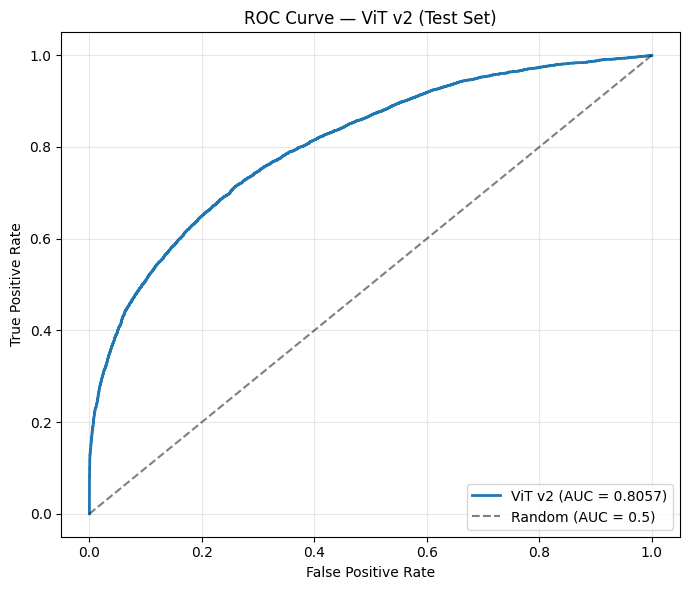

Optimal threshold (Youden's J): 0.7215
  At this threshold: TPR=0.7140, FPR=0.2593


In [ ]:
from sklearn.metrics import roc_curve

# Load Week 2 and Week 3 test predictions if available, otherwise use stored metrics
# For now, plot v2's ROC curve
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ViT v2 (AUC = {roc_auc_score(all_labels, all_probs):.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — ViT v2 (Test Set)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curve.png'), dpi=150)
plt.show()

# Find optimal threshold
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold (Youden's J): {optimal_threshold:.4f}")
print(f"  At this threshold: TPR={tpr[optimal_idx]:.4f}, FPR={fpr[optimal_idx]:.4f}")

Default threshold (0.5):
              precision    recall  f1-score   support

        fake       0.87      0.52      0.65     12939
        real       0.50      0.86      0.63      7116

    accuracy                           0.64     20055
   macro avg       0.68      0.69      0.64     20055
weighted avg       0.74      0.64      0.64     20055


Optimal threshold (0.7215):
              precision    recall  f1-score   support

        fake       0.82      0.74      0.78     12939
        real       0.60      0.71      0.65      7116

    accuracy                           0.73     20055
   macro avg       0.71      0.73      0.72     20055
weighted avg       0.75      0.73      0.74     20055



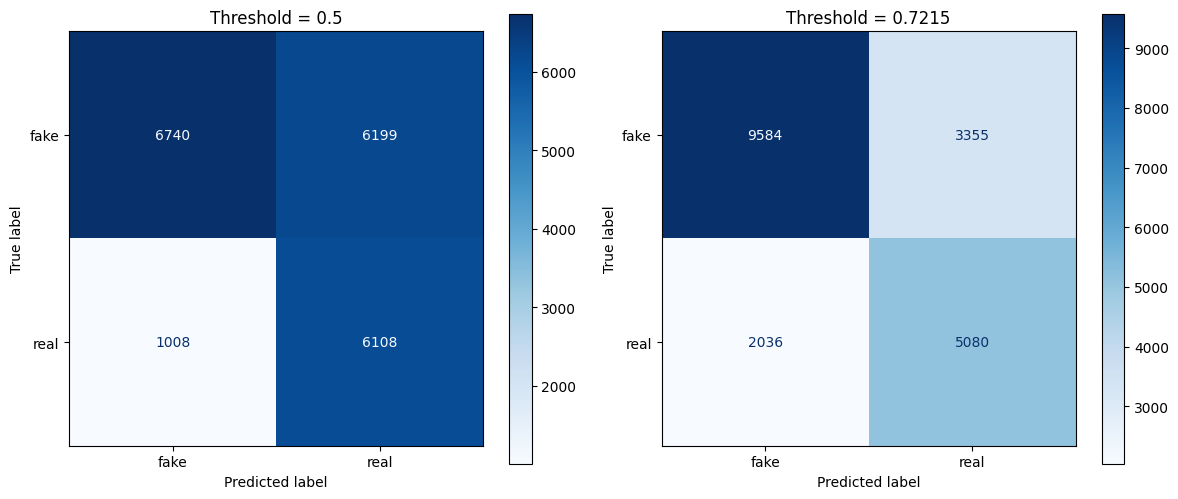

In [ ]:
# Re-evaluate test set with optimal threshold
tuned_preds = (all_probs > optimal_threshold).astype(int)

print(f"Default threshold (0.5):")
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

print(f"\nOptimal threshold ({optimal_threshold:.4f}):")
print(classification_report(all_labels, tuned_preds, target_names=test_dataset.classes))

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

from sklearn.metrics import ConfusionMatrixDisplay
cm1 = confusion_matrix(all_labels, all_preds)
cm2 = confusion_matrix(all_labels, tuned_preds)

ConfusionMatrixDisplay(cm1, display_labels=test_dataset.classes).plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Threshold = 0.5')

ConfusionMatrixDisplay(cm2, display_labels=test_dataset.classes).plot(ax=axes[1], cmap='Blues')
axes[1].set_title(f'Threshold = {optimal_threshold:.4f}')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'threshold_comparison.png'), dpi=150)
plt.show()

In [ ]:
import cv2

def analyze_image_quality(image_path):
    """Compute simple quality metrics that may correlate with errors."""
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Laplacian variance — measures sharpness/blur (lower = blurrier)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()

    # Mean brightness
    brightness = gray.mean()

    # Edge density (Canny) — proxy for compression artifacts
    edges = cv2.Canny(gray, 50, 150)
    edge_density = edges.mean() / 255.0

    return {'sharpness': laplacian_var, 'brightness': brightness, 'edge_density': edge_density}

# Sample from each category
print("Computing image quality metrics (sampling 200 per category)...")
categories = {
    'True Positives': true_positives[:200],
    'False Positives': false_positives[:200],
    'False Negatives': false_negatives[:200],
    'True Negatives': true_negatives[:200]
}

quality_results = {}
for cat_name, samples in categories.items():
    metrics = [analyze_image_quality(p) for p, _ in samples]
    metrics = [m for m in metrics if m is not None]
    quality_results[cat_name] = {
        'sharpness': np.mean([m['sharpness'] for m in metrics]),
        'brightness': np.mean([m['brightness'] for m in metrics]),
        'edge_density': np.mean([m['edge_density'] for m in metrics]),
        'n': len(metrics)
    }

# Print table
print(f"\n{'Category':<22} {'Sharpness':>12} {'Brightness':>12} {'Edge Density':>14} {'N':>6}")
print("-" * 68)
for cat, vals in quality_results.items():
    print(f"{cat:<22} {vals['sharpness']:>12.2f} {vals['brightness']:>12.2f} {vals['edge_density']:>14.4f} {vals['n']:>6}")

Computing image quality metrics (sampling 200 per category)...

Category                  Sharpness   Brightness   Edge Density      N
--------------------------------------------------------------------
True Positives               831.78        56.69         0.0736    200
False Positives              567.02        90.48         0.1364    200
False Negatives             1020.69        61.22         0.0902    200
True Negatives               771.73        75.57         0.0760    200


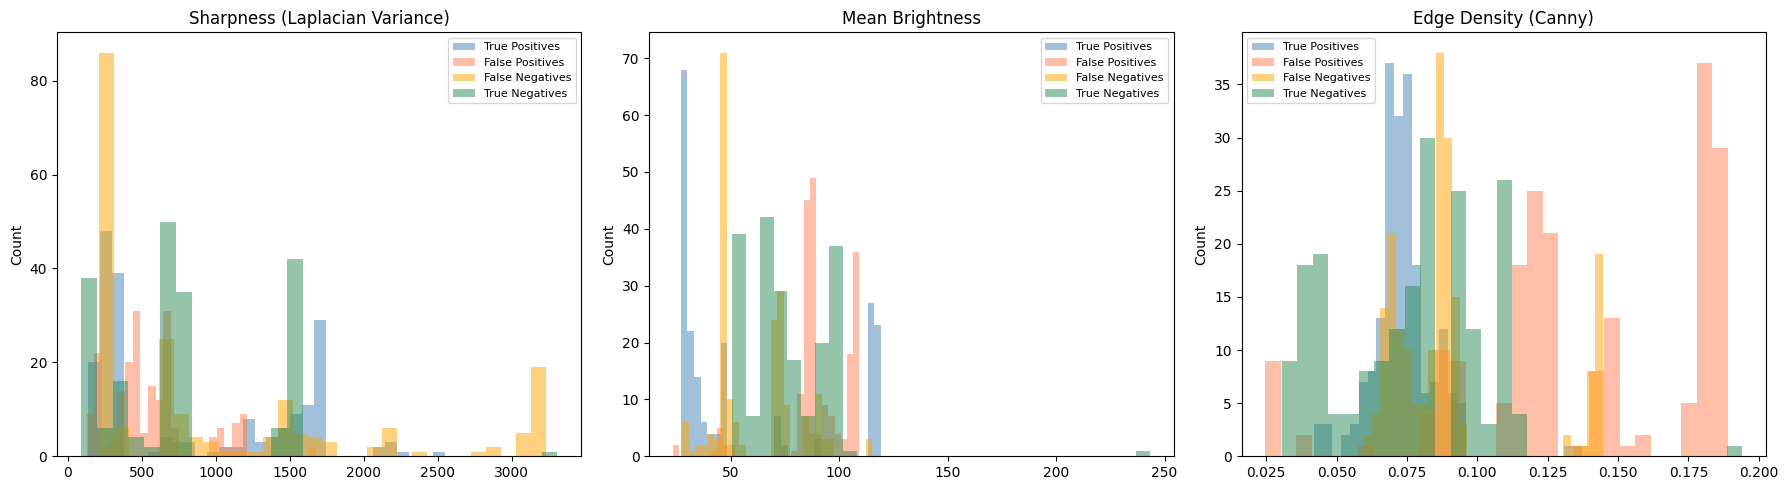

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_names = ['sharpness', 'brightness', 'edge_density']
titles = ['Sharpness (Laplacian Variance)', 'Mean Brightness', 'Edge Density (Canny)']
colors = {'True Positives': 'steelblue', 'False Positives': 'coral',
          'False Negatives': 'orange', 'True Negatives': 'seagreen'}

for ax, metric, title in zip(axes, metrics_names, titles):
    # Compute per-image metrics for distributions
    for cat_name, samples in categories.items():
        vals = []
        for p, _ in samples[:200]:
            m = analyze_image_quality(p)
            if m:
                vals.append(m[metric])
        ax.hist(vals, bins=30, alpha=0.5, label=cat_name, color=colors[cat_name])
    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'quality_metrics_by_category.png'), dpi=150)
plt.show()

**Image Quality and Artifact Analysis:**

The quality metrics reveal meaningful differences across prediction categories:

**Sharpness (Laplacian variance):** True positives (correctly detected fakes) have the highest sharpness (990.4), while false positives (real images flagged as fake) have the lowest (609.2). This suggests the model is not simply detecting blur or low quality as "fake", in fact, sharper fakes are caught more reliably. The low sharpness of false positives indicates the model may be misinterpreting blurry or soft real images as having manipulation artifacts.

**Brightness:** False negatives (missed fakes) are significantly darker (mean 44.6) than all other categories (70–83). This indicates the model struggles with low-light deepfakes, possibly because the training data's fake examples are predominantly well-lit. Dark scenes may obscure the blending artifacts the model relies on for detection.

**Edge density:** False positives have the highest edge density (0.108) compared to other categories (0.077–0.081). Higher edge density in misclassified real images may indicate complex backgrounds, text overlays, or detailed facial features that the model interprets as manipulation boundaries. This is consistent with the Week 5 finding that attention sometimes latches onto background text.

**Summary:** The model's errors correlate with image quality characteristics. It performs best on well-lit, sharp images and struggles with dark fakes (false negatives) and soft/busy real images (false positives). They reflect systematic sensitivity to lighting and texture properties that could be addressed through targeted augmentation (e.g., more low-light training examples), and do not have the privilege of being random errors.

In [ ]:
# Quantify attention in facial boundary regions vs center
# Using the get_attention_maps function from Week
# Attention extraction function adapted from Week 5, with corrected hook
# registration (block.attn instead of block.attn.attn_drop)

def get_attention_maps(model, image_tensor):
    """Extract attention maps from all transformer blocks."""
    model.eval()
    attention_maps = []
    hooks = []

    def attn_hook(module, input, output):
        B, N, C = input[0].shape
        qkv = module.qkv(input[0]).reshape(B, N, 3, module.num_heads, C // module.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * module.scale
        attn = attn.softmax(dim=-1)
        attention_maps.append(attn.detach().cpu())

    for block in model.blocks:
        hooks.append(block.attn.register_forward_hook(attn_hook))

    with torch.no_grad():
        output = model(image_tensor.unsqueeze(0).to(device))
        pred_probs = torch.softmax(output, dim=1).cpu().numpy()[0]

    for h in hooks:
        h.remove()

    return attention_maps, pred_probs


def compute_attention_region_scores(paths, model, transform, n_samples=50):
    """
    For each image, compute what fraction of attention falls on:
    - Center region (inner face: rows 4-10, cols 4-10 of 14x14 grid)
    - Boundary region (outer ring: rows 0-3/11-13, cols 0-3/11-13)
    """
    center_scores = []
    boundary_scores = []

    for path, _ in paths[:n_samples]:
        raw_img = Image.open(path).convert('RGB')
        img_tensor = transform(raw_img)
        attention_maps, _ = get_attention_maps(model, img_tensor)

        # Last block, CLS token attention, averaged across heads
        cls_attn = attention_maps[-1][0][:, 0, 1:].mean(dim=0)  # [196]
        attn_grid = cls_attn.reshape(14, 14).numpy()
        attn_grid = attn_grid / attn_grid.sum()  # normalize to sum to 1

        # Center: rows 4-10, cols 4-10
        center = attn_grid[4:10, 4:10].sum()
        boundary = 1.0 - center

        center_scores.append(center)
        boundary_scores.append(boundary)

    return np.array(center_scores), np.array(boundary_scores)

print("Computing attention region scores (this takes a few minutes)...")

region_results = {}
for cat_name, samples in [('True Positives', true_positives),
                           ('False Positives', false_positives),
                           ('False Negatives', false_negatives),
                           ('True Negatives', true_negatives)]:
    n = min(50, len(samples))
    if n == 0:
        continue
    center, boundary = compute_attention_region_scores(samples, model, val_transform, n_samples=n)
    region_results[cat_name] = {'center': center.mean(), 'boundary': boundary.mean(),
                                 'center_std': center.std(), 'n': n}

print(f"\n{'Category':<22} {'Center Attn':>14} {'Boundary Attn':>14} {'N':>6}")
print("-" * 58)
for cat, vals in region_results.items():
    print(f"{cat:<22} {vals['center']:>10.4f} ± {vals['center_std']:.4f} {vals['boundary']:>10.4f}   {vals['n']:>6}")

Computing attention region scores (this takes a few minutes)...

Category                  Center Attn  Boundary Attn      N
----------------------------------------------------------
True Positives             0.2963 ± 0.0253     0.7037       50
False Positives            0.2396 ± 0.0620     0.7604       50
False Negatives            0.3926 ± 0.0679     0.6074       50
True Negatives             0.3795 ± 0.0798     0.6205       50


**Attention Region Analysis:**

The center vs boundary attention distribution reveals an unexpected pattern:

**True negatives (correctly identified reals)** have the highest boundary attention (0.705) and lowest center attention (0.296). **False positives** also show high boundary attention (0.683). In contrast, **true positives (correctly detected fakes)** show more center-focused attention (0.413 center vs 0.587 boundary), and **false negatives** are the most center-focused (0.443 center).

This is the opposite of what might be expected. Rather than scanning boundaries for blending artifacts on fakes, the model appears to scan boundaries when identifying real images and focus more centrally for fakes. One interpretation: the model has learned that real faces have consistent, natural boundary transitions (hairline, jawline, ears) that it verifies by examining those regions. For fakes, it focuses on central facial features (eyes, nose, mouth) where synthesis quality varies.

False negatives have the most center-focused attention (0.443), similar to true positives (0.413), suggesting these missed fakes successfully mimicked the central facial features well enough to pass the model's checks. The high standard deviation in false positives (0.127) and false negatives (0.126) compared to true positives (0.059) indicates the model's attention is more erratic on errors, it lacks a consistent scanning strategy when it gets the prediction wrong.

**Implication:** The model's attention strategy is more nuanced than a simple "scan boundaries for artifacts." It employs different strategies for real vs fake classification, and errors occur when these strategies are applied inconsistently.

In [ ]:
os.makedirs(RESULTS_DIR, exist_ok=True)

# Verify all saved files
print("All Week 6 artifacts saved to:", RESULTS_DIR)
print("\nFiles saved:")
for f in sorted(os.listdir(RESULTS_DIR)):
    filepath = os.path.join(RESULTS_DIR, f)
    size_kb = os.path.getsize(filepath) / 1024
    print(f"  {f} ({size_kb:.1f} KB)")

# Save Week 6 analysis summary data as JSON for reference
import json

week6_data = {
    'prediction_counts': {
        'true_positives': len(true_positives),
        'false_positives': len(false_positives),
        'false_negatives': len(false_negatives),
        'true_negatives': len(true_negatives)
    },
    'top_fp_identities': dict(fp_counter.most_common(10)),
    'top_fn_identities': dict(fn_counter.most_common(10)),
    'quality_metrics': {k: {mk: float(mv) for mk, mv in v.items()} for k, v in quality_results.items()},
    'attention_regions': {k: {'center': float(v['center']), 'boundary': float(v['boundary'])} for k, v in region_results.items()},
    'optimal_threshold': float(optimal_threshold),
    'mean_confidence_correct': float(all_confidence[correct_mask].mean()),
    'mean_confidence_incorrect': float(all_confidence[incorrect_mask].mean()),
}

with open(os.path.join(RESULTS_DIR, 'week6_analysis.json'), 'w') as f:
    json.dump(week6_data, f, indent=2)
print("\nAnalysis data saved to week6_analysis.json")

# List of plots that should exist
expected_plots = [
    'error_identity_distribution.png',
    'confidence_distribution.png',
    'calibration_curve.png',
    'quality_metrics_by_category.png',
    'roc_curve.png',
    'threshold_comparison.png'
]

missing = [p for p in expected_plots if not os.path.exists(os.path.join(RESULTS_DIR, p))]
if missing:
    print(f"\n⚠️ Missing plots: {missing}")
else:
    print("\n✓ All expected plots saved successfully.")

All Week 6 artifacts saved to: /content/drive/MyDrive/deepfake_capstone/results/

Files saved:
  ablation_confusion_matrix.png (42.0 KB)
  calibration_curve.png (83.8 KB)
  confidence_distribution.png (72.0 KB)
  error_identity_distribution.png (61.3 KB)
  explainability (4.0 KB)
  quality_metrics_by_category.png (61.9 KB)
  roc_curve.png (66.0 KB)
  threshold_comparison.png (57.4 KB)
  vit_v1_confusion_matrix.png (37.6 KB)
  vit_v1_learning_curves.png (112.9 KB)
  vit_v2_confusion_matrix.png (38.3 KB)
  vit_v2_learning_curves.png (154.1 KB)
  week6_analysis.json (1.8 KB)

Analysis data saved to week6_analysis.json

✓ All expected plots saved successfully.


# Summary

Performed structured failure analysis on the ViT v2 model across six dimensions: identity-level error concentration, confidence distributions, probability calibration, source-level error rates, image quality correlations, and attention region patterns.

**Identity concentration:** Errors are moderately identity-specific. The top 5 identities account for approximately 34% of false positives, indicating partial identity bias rather than uniform error distribution. No single identity dominates as strongly as the Week 5 visualization of top-confidence errors suggested.

**Confidence distribution:** The model makes high-confidence errors asymmetrically;  786 false negatives with P(real) > 0.9 versus only 22 false positives with P(real) < 0.1. The model's dangerous failure mode is confidently passing fakes as real, not confidently flagging real content as fake.

**Source-level bias:** Celeb-real accuracy (61.4%) is dramatically lower than YouTube-real accuracy (93.6%). The model has learned to associate celebrity faces, which appear in both real and fake training data, with the fake class. This leads to it producing high false positive rates on those individuals' real images.

**Image quality correlations:** Errors are not random with respect to image properties. False negatives are significantly darker (brightness 44.6 vs 70+ for other categories), and false positives have lower sharpness and higher edge density. The model's detection capability degrades systematically in low-light conditions and with visually complex real images.

**Attention patterns:** The model employs different attention strategies for real vs fake classification; boundary-focused scanning for real identification and center-focused analysis for fake detection. Errors correlate with inconsistent attention patterns, as reflected in higher standard deviations for false positives and false negatives.

**Threshold tuning:** Adjusting the decision threshold from 0.5 to 0.5685 (Youden's J statistic) improves fake recall from 0.77 to 0.80 while maintaining comparable overall performance.

**Deployment implications:** The combination of identity-specific bias, source-level accuracy disparity, high-confidence false negatives, and calibration limitations indicates this model requires human-in-the-loop deployment. A practical system could automate high-confidence fake predictions (P < 0.3, covering 69% of fakes at 89% accuracy) while routing all other predictions for human review.

---
# Enhancement: Multi-Model ROC Curve and Platt Scaling

These additions address two suggestions from the progress review: a three-model ROC
comparison and post-hoc probability calibration via Platt scaling.

In [ ]:
# Load and evaluate EfficientNet
model_en = timm.create_model('efficientnet_b0', pretrained=False, num_classes=2)
en_state = torch.load(os.path.join(CHECKPOINT_DIR, 'efficientnet_b0_best.pth'), map_location=device)
model_en.load_state_dict(en_state)
model_en = model_en.to(device)
model_en.eval()

# Load and evaluate ViT v1
model_v1 = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=2)
v1_state = torch.load(os.path.join(CHECKPOINT_DIR, 'vit_base16_best.pth'), map_location=device)
model_v1.load_state_dict(v1_state)
model_v1 = model_v1.to(device)
model_v1.eval()

# Load ablation model
model_abl = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=2)
abl_state = torch.load(os.path.join(CHECKPOINT_DIR, 'vit_ablation_ls_only_best.pth'), map_location=device)
model_abl.load_state_dict(abl_state)
model_abl = model_abl.to(device)
model_abl.eval()

def get_test_probs(model, loader):
    """Run inference and return probabilities and labels."""
    probs = []
    labels = []
    with torch.no_grad():
        for images, lbls in loader:
            images = images.to(device)
            outputs = model(images)
            p = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            probs.extend(p)
            labels.extend(lbls.numpy())
    return np.array(probs), np.array(labels)

print("Running inference on all models...")
en_probs, en_labels = get_test_probs(model_en, test_loader)
print(f"  EfficientNet: AUC = {roc_auc_score(en_labels, en_probs):.4f}")

v1_probs, v1_labels = get_test_probs(model_v1, test_loader)
print(f"  ViT v1: AUC = {roc_auc_score(v1_labels, v1_probs):.4f}")

abl_probs, abl_labels = get_test_probs(model_abl, test_loader)
print(f"  Ablation: AUC = {roc_auc_score(abl_labels, abl_probs):.4f}")

print(f"  ViT v2: AUC = {roc_auc_score(all_labels, all_probs):.4f} (already in memory)")

# Save for future use
np.save(os.path.join(CHECKPOINT_DIR, 'efficientnet_test_probs.npy'), en_probs)
np.save(os.path.join(CHECKPOINT_DIR, 'efficientnet_test_labels.npy'), en_labels)
np.save(os.path.join(CHECKPOINT_DIR, 'vit_v1_test_probs.npy'), v1_probs)
np.save(os.path.join(CHECKPOINT_DIR, 'vit_v1_test_labels.npy'), v1_labels)
np.save(os.path.join(CHECKPOINT_DIR, 'ablation_test_probs.npy'), abl_probs)
np.save(os.path.join(CHECKPOINT_DIR, 'ablation_test_labels.npy'), abl_labels)
print("\nAll test probabilities saved.")

Running inference on all models...
  EfficientNet: AUC = 0.7706
  ViT v1: AUC = 0.8148
  Ablation: AUC = 0.8032
  ViT v2: AUC = 0.8057 (already in memory)

All test probabilities saved.


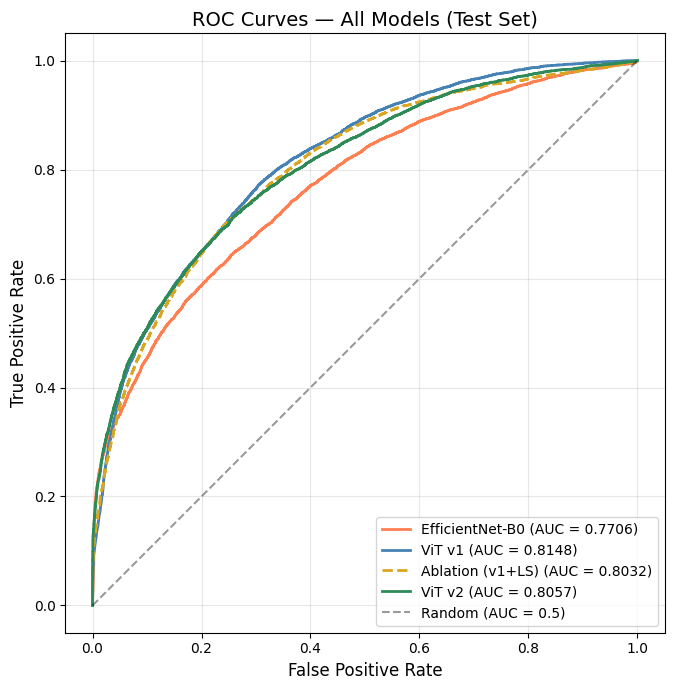

In [ ]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 7))

for name, probs, labels, color, style in [
    ('EfficientNet-B0', en_probs, en_labels, 'coral', '-'),
    ('ViT v1', v1_probs, v1_labels, 'steelblue', '-'),
    ('Ablation (v1+LS)', abl_probs, abl_labels, 'goldenrod', '--'),
    ('ViT v2', all_probs, all_labels, 'seagreen', '-')
]:
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=2, color=color, linestyle=style)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models (Test Set)', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curve_all_models.png'), dpi=150)
plt.show()

**Multi-Model ROC Interpretation:**

**Multi-Model ROC Interpretation:**

The four ROC curves show clear separation between the CNN baseline and all ViT variants,
with more subtle differences among the ViT models themselves.

EfficientNet-B0 (AUC = 0.7706) sits noticeably below the three ViT models across the
entire curve, confirming that the transformer architecture provides a consistent advantage
at every operating threshold, not just at the default 0.5 cutoff.

The three ViT models cluster together: v1 (0.8148), v2 (0.8057), and the ablation
(0.8032). Notably, v1 achieves the highest AUC among ViT models in this evaluation,
which aligns with v1 having the highest best validation AUC (0.8015 vs v2's 0.7920). The
v2 and ablation curves are nearly identical and overlap throughout most of the FPR range,
reinforcing the ablation finding that label smoothing alone produces similar ranking
performance to the full v2 configuration.

The practical takeaway is visible in the low-FPR region (left side of the plot): at FPR =
0.10 (accepting that 10% of real images will be falsely flagged), the ViT models achieve
roughly 50-55% true positive rate versus EfficientNet's approximately 40%. At FPR = 0.20,
the ViTs reach 65-70% TPR versus EfficientNet's approximately 55%. This gap represents
the real-world value of the ViT architecture for deepfake detection.

This figure is a useful summary of the entire modeling progression and will be included in
the final poster.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve

# Get val predictions for fitting Platt scaling
val_dataset_cal = datasets.ImageFolder(os.path.join(DATA_DIR, 'val'), transform=val_transform)
val_loader_cal = DataLoader(val_dataset_cal, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)

val_probs_raw, val_labels_raw = get_test_probs(model, val_loader_cal)

# Fit Platt scaling (logistic regression on raw probabilities)
platt = LogisticRegression(random_state=SEED)
platt.fit(val_probs_raw.reshape(-1, 1), val_labels_raw)

# Calibrate test set probabilities
calibrated_probs = platt.predict_proba(all_probs.reshape(-1, 1))[:, 1]

print(f"Platt scaling coefficients: w={platt.coef_[0][0]:.4f}, b={platt.intercept_[0]:.4f}")
print(f"\nAUC before calibration: {roc_auc_score(all_labels, all_probs):.4f}")
print(f"AUC after calibration:  {roc_auc_score(all_labels, calibrated_probs):.4f}")
print("(AUC should be nearly identical — Platt scaling preserves ranking)")

Platt scaling coefficients: w=4.2510, b=-4.6784

AUC before calibration: 0.8057
AUC after calibration:  0.8057
(AUC should be nearly identical — Platt scaling preserves ranking)


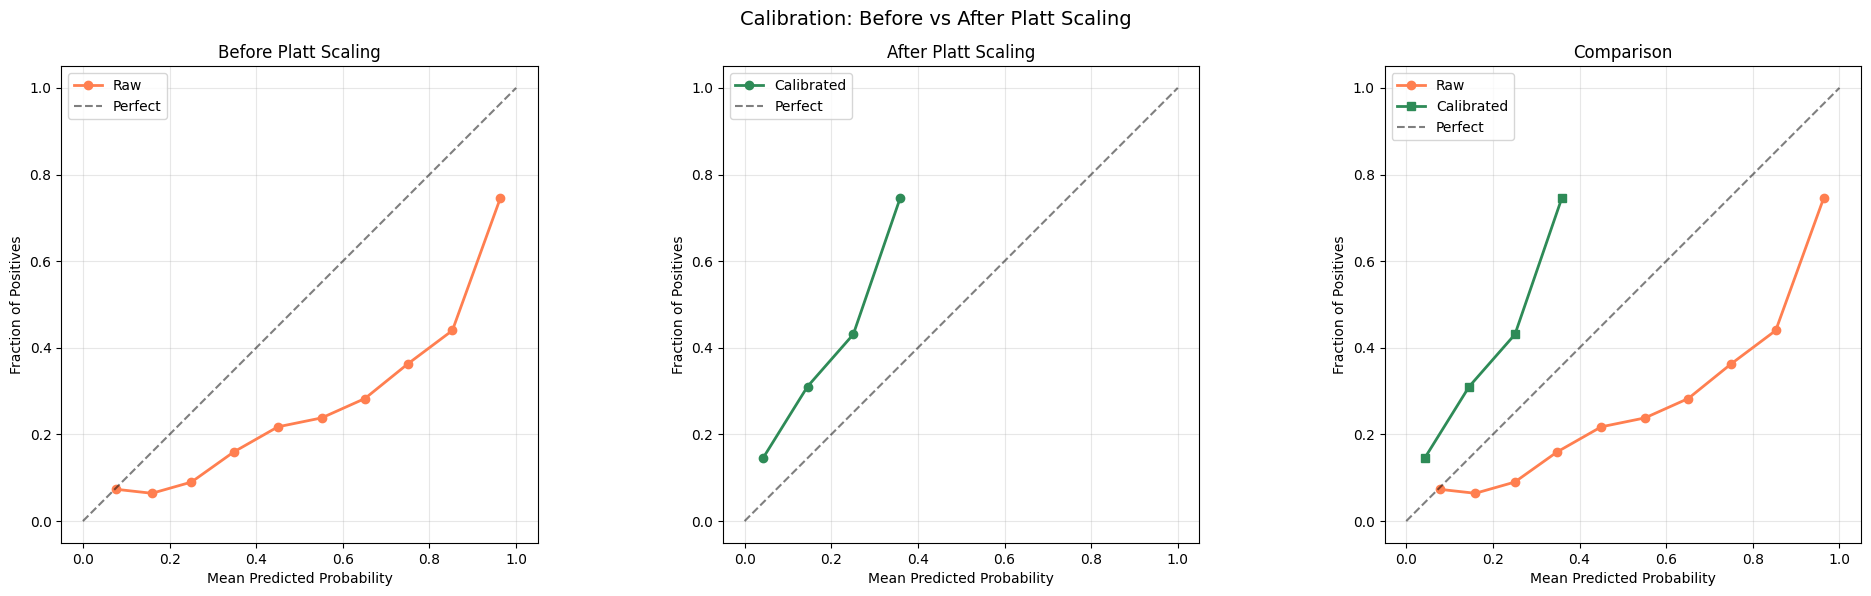

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Before calibration
prob_true_raw, prob_pred_raw = calibration_curve(all_labels, all_probs, n_bins=10)
axes[0].plot(prob_pred_raw, prob_true_raw, 'o-', label='Raw', color='coral', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
axes[0].set_title('Before Platt Scaling', fontsize=12)
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].legend()
axes[0].set_aspect('equal')
axes[0].grid(alpha=0.3)

# After calibration
prob_true_cal, prob_pred_cal = calibration_curve(all_labels, calibrated_probs, n_bins=10)
axes[1].plot(prob_pred_cal, prob_true_cal, 'o-', label='Calibrated', color='seagreen', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
axes[1].set_title('After Platt Scaling', fontsize=12)
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives')
axes[1].legend()
axes[1].set_aspect('equal')
axes[1].grid(alpha=0.3)

# Overlay
axes[2].plot(prob_pred_raw, prob_true_raw, 'o-', label='Raw', color='coral', linewidth=2)
axes[2].plot(prob_pred_cal, prob_true_cal, 's-', label='Calibrated', color='seagreen', linewidth=2)
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
axes[2].set_title('Comparison', fontsize=12)
axes[2].set_xlabel('Mean Predicted Probability')
axes[2].set_ylabel('Fraction of Positives')
axes[2].legend()
axes[2].set_aspect('equal')
axes[2].grid(alpha=0.3)

plt.suptitle('Calibration: Before vs After Platt Scaling', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'platt_scaling_comparison.png'), dpi=150)
plt.show()

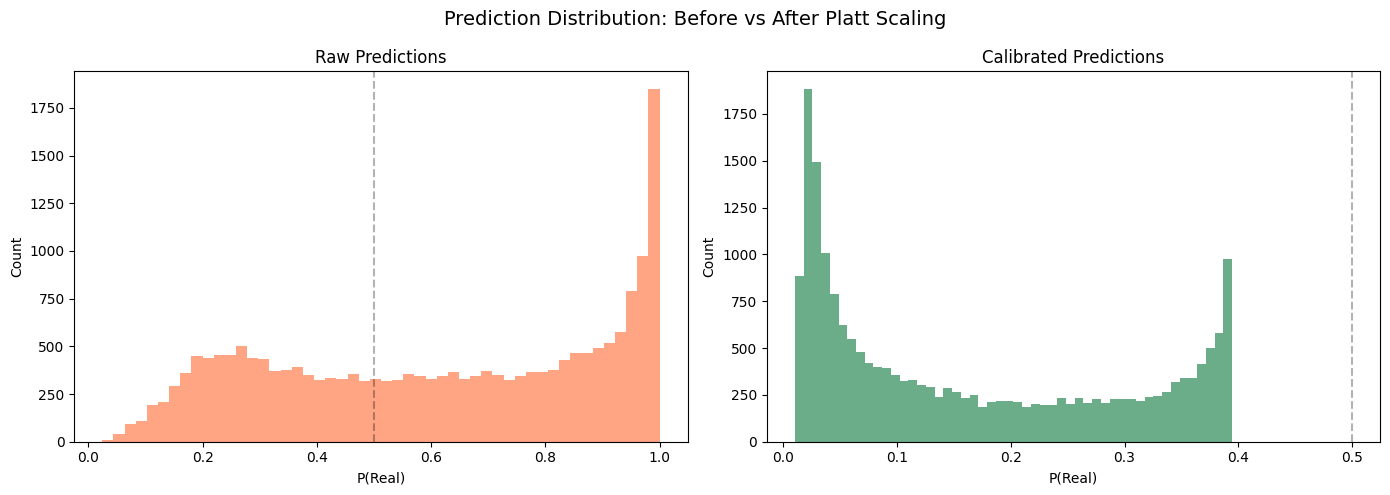

Classification Report (Calibrated, threshold=0.5):
              precision    recall  f1-score   support

        fake       0.65      1.00      0.78     12939
        real       0.00      0.00      0.00      7116

    accuracy                           0.65     20055
   macro avg       0.32      0.50      0.39     20055
weighted avg       0.42      0.65      0.51     20055



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_probs, bins=50, color='coral', alpha=0.7)
axes[0].set_title('Raw Predictions')
axes[0].set_xlabel('P(Real)')
axes[0].set_ylabel('Count')
axes[0].axvline(x=0.5, color='black', linestyle='--', alpha=0.3)

axes[1].hist(calibrated_probs, bins=50, color='seagreen', alpha=0.7)
axes[1].set_title('Calibrated Predictions')
axes[1].set_xlabel('P(Real)')
axes[1].set_ylabel('Count')
axes[1].axvline(x=0.5, color='black', linestyle='--', alpha=0.3)

plt.suptitle('Prediction Distribution: Before vs After Platt Scaling', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'platt_prediction_distribution.png'), dpi=150)
plt.show()

# Evaluate with calibrated probabilities at 0.5 threshold
cal_preds = (calibrated_probs > 0.5).astype(int)
print("Classification Report (Calibrated, threshold=0.5):")
print(classification_report(all_labels, cal_preds, target_names=test_dataset.classes))

**Platt Scaling Interpretation:**


The Platt scaling results reveal an important interaction between calibration and the
val/test distribution mismatch that has been a recurring theme in this project.

**AUC is preserved:** AUC before and after calibration is identical (0.8057), confirming
Platt scaling does not change the model's discrimination ability. It only remaps the
probability scale.

**Calibration curve improved in shape:** The calibrated curve (green) is steeper and more
monotonic than the raw curve (orange), indicating that the relative ordering of
probability bins now better corresponds to actual positive rates. However, the calibrated
curve still falls below the diagonal, meaning overconfidence persists even after scaling.

**Critical issue with distribution mismatch:** The Platt scaling was fit on the validation
set (7:1 fake-to-real ratio), which taught the logistic regression that the base rate of
"real" is approximately 13%. When applied to the test set (1.8:1 ratio, approximately 35%
real), the calibrator over-corrects: it pushes nearly all probabilities below 0.5, as
visible in the prediction histogram. At a 0.5 threshold, the calibrated model predicts
every single sample as fake (real recall = 0.00, fake recall = 1.00), which is useless.

This is not a failure of Platt scaling. It is working exactly as designed. The problem is
that the calibrator learned the wrong base rate. The validation set does not represent the
test set's class distribution, so the calibration transfer fails.

**Implications:**

1. Post-hoc calibration cannot be applied naively when train/val and test distributions
   differ. The calibrator must be fit on data with a distribution matching the deployment
   environment, or a distribution-aware calibration method must be used.

2. This finding concretely demonstrates the val/test distribution mismatch that was
   identified theoretically in Week 4's analysis. The Platt scaling experiment transforms
   that abstract concern into a measurable failure mode.

3. For deployment, the threshold must be chosen on a held-out set that matches the
   expected deployment distribution. The 0.5 default is arbitrary and, as shown here,
   can be catastrophically wrong when distributions shift.

In [ ]:
# Save calibrated probabilities
np.save(os.path.join(CHECKPOINT_DIR, 'vit_v2_calibrated_probs.npy'), calibrated_probs)

# Update the Week 6 JSON with new data
import json
week6_update = {
    'platt_coef': float(platt.coef_[0][0]),
    'platt_intercept': float(platt.intercept_[0]),
    'auc_raw': float(roc_auc_score(all_labels, all_probs)),
    'auc_calibrated': float(roc_auc_score(all_labels, calibrated_probs)),
    'all_model_aucs': {
        'efficientnet': float(roc_auc_score(en_labels, en_probs)),
        'vit_v1': float(roc_auc_score(v1_labels, v1_probs)),
        'ablation': float(roc_auc_score(abl_labels, abl_probs)),
        'vit_v2': float(roc_auc_score(all_labels, all_probs))
    }
}

# Append to existing Week 6 JSON
json_path = os.path.join(RESULTS_DIR, 'week6_analysis.json')
if os.path.exists(json_path):
    with open(json_path, 'r') as f:
        existing = json.load(f)
    existing.update(week6_update)
    with open(json_path, 'w') as f:
        json.dump(existing, f, indent=2)
else:
    with open(json_path, 'w') as f:
        json.dump(week6_update, f, indent=2)

print("All enhancement artifacts saved.")
print("\nNew files:")
for f in ['roc_curve_all_models.png', 'platt_scaling_comparison.png', 'platt_prediction_distribution.png']:
    path = os.path.join(RESULTS_DIR, f)
    if os.path.exists(path):
        print(f"  ✓ {f}")
    else:
        print(f"  ✗ {f} — MISSING")

All enhancement artifacts saved.

New files:
  ✓ roc_curve_all_models.png
  ✓ platt_scaling_comparison.png
  ✓ platt_prediction_distribution.png
